In [4]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.optimize import least_squares
import surfinBH
import gwsurrogate as gws
import sympy as sp
from IPython.display import display, Math
import lal
from tqdm.auto import tqdm
from pathlib import Path
import sqlite3
lal.swig_redirect_standard_output_error(False)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


True

In [5]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


### 2PN binding energy and total angular momentum in Blanchet radial convention

In this cell we construct a reduced circular-orbit PN model for the conservative binding energy and the total angular momentum of a spinning compact binary system up to 2PN order. The implementation follows the radial PN parametrization used in Blanchet-type circular-orbit formulae.

We keep explicit powers of the speed of light $c$ and introduce the PN bookkeeping parameter

$$
\epsilon = \frac{1}{c}.
$$

The radial PN variable is

$$
\Gamma = \frac{Gm}{r},
$$

where $r$ is the binary separation and

$$
m = m_1 + m_2.
$$

In the numerical implementation, the precession code provides the dimensionless separation

$$
a_{\rm prec} = \frac{r}{m}.
$$

Therefore,

$$
\Gamma = \frac{G}{a_{\rm prec}}.
$$

The mass parameters are

$$
m = m_1 + m_2,
\qquad
\mu = \frac{m_1m_2}{m},
\qquad
\nu = \frac{\mu}{m}.
$$

The non-spinning circular binding energy up to 2PN order in the radial variable $\Gamma$ is

$$
E_{\rm NS}(\Gamma)
=

-\frac{\mu\Gamma}{2}
+
\frac{\mu\Gamma^2}{8c^2}
\left(7-\nu\right)
+
\frac{\mu\Gamma^3}{16c^4}
\left(7-49\nu-\nu^2\right).
$$

The leading spin-orbit contribution enters at 1.5PN order. Defining

$$
B_{\rm SO}
=

S_{1L}
\left(
4m_1m_2+3m_2^2
\right)
+
S_{2L}
\left(
3m_1^2+4m_1m_2
\right),
$$

we use

$$
E_{\rm SO}^{1.5{\rm PN}}(\Gamma)
=

-

\frac{\mu\Gamma^{5/2}}{3Gm^2m_1m_2c^3}
B_{\rm SO}.
$$

The leading spin-spin sector enters at 2PN order. It contains both the mutual interaction $S_1S_2$ and the self-spin, or spin-induced quadrupole, terms. For the mutual term we define

$$
B_{\rm SS}^{12}
=

-\mathbf S_1\cdot\mathbf S_2
+
3S_{1L}S_{2L},
$$

so that

$$
E_{\rm SS}^{12}(\Gamma)
=

-

\frac{\Gamma^3}{2G^2m^3c^4}
B_{\rm SS}^{12}.
$$

For the self-spin terms we define

$$
B_{\rm SS}^{11}
=

-\mathbf S_1^2
+
3S_{1L}^2,
\qquad
B_{\rm SS}^{22}
=

-\mathbf S_2^2
+
3S_{2L}^2.
$$

For Kerr black holes the spin-induced quadrupole coefficients are fixed to

$$
C_{Q1}=C_{Q2}=1.
$$

Therefore, the Kerr self-spin contribution is

$$
E_{\rm SS}^{\rm self}(\Gamma)
=

-

\frac{\Gamma^3}{4G^2m^3c^4}
\left[
\frac{m_2}{m_1}
B_{\rm SS}^{11}
+
\frac{m_1}{m_2}
B_{\rm SS}^{22}
\right].
$$

The conservative binding energy used in this cell is therefore

$$
E_{\rm bind}(\Gamma)
=

E_{\rm NS}(\Gamma)
+
E_{\rm SO}^{1.5{\rm PN}}(\Gamma)
+
E_{\rm SS}^{12}(\Gamma)
+
E_{\rm SS}^{\rm self}(\Gamma).
$$

The total mass used in the Kerr entropy is obtained from the binding energy as

$$
M_{\rm tot}
=

m+\frac{E_{\rm bind}}{c^2}.
$$

The non-spinning orbital angular momentum up to 2PN order in the radial variable $\Gamma$ is

$$
L_{\rm NS}(\Gamma)
=

\frac{G\mu m}{\sqrt{\Gamma}}
+
\frac{2G\mu m\sqrt{\Gamma}}{c^2}
+
\frac{G\mu m\Gamma^{3/2}}{2c^4}
\left(5-9\nu\right).
$$

The leading spin-orbit correction to the orbital angular momentum enters at 1.5PN order. Its components on the orbital triad $(\mathbf n,\boldsymbol{\lambda},\boldsymbol{\ell})$ are

$$
L_{\ell,{\rm SO}}^{1.5{\rm PN}}
=

-

\frac{5\Gamma}{6m^2c^3}
B_{\rm SO},
$$

$$
L_{n,{\rm SO}}^{1.5{\rm PN}}
=

\frac{\Gamma}{2m^2c^3}
\left(
m_2^2S_{1n}
+
m_1^2S_{2n}
\right),
$$

$$
L_{\lambda,{\rm SO}}^{1.5{\rm PN}}
=

-

\frac{\Gamma}{m^2c^3}
\left[
m_2(2m_1+m_2)S_{1\lambda}
+
m_1(m_1+2m_2)S_{2\lambda}
\right].
$$

In the reduced circular-orbit model we also add a leading spin-spin correction to the orbital angular momentum along $\boldsymbol{\ell}$. We define

$$
B_{\rm SS}^{\rm self}
=

\frac{m_2}{m_1}
B_{\rm SS}^{11}
+
\frac{m_1}{m_2}
B_{\rm SS}^{22},
$$

and

$$
B_{\rm SS}^{\rm tot}
=

B_{\rm SS}^{12}
+
\frac{1}{2}
B_{\rm SS}^{\rm self}.
$$

The reduced spin-spin angular-momentum correction is then

$$
L_{\ell,{\rm SS}}^{2{\rm PN}}
=

-

\frac{\Gamma^{3/2}}{Gm^2c^4}
B_{\rm SS}^{\rm tot},
$$

with

$$
L_{n,{\rm SS}}^{2{\rm PN}}=0,
\qquad
L_{\lambda,{\rm SS}}^{2{\rm PN}}=0.
$$

Thus, the orbital angular-momentum components used in the calculation are

$$
L_\ell
=

L_{\rm NS}
+
L_{\ell,{\rm SO}}^{1.5{\rm PN}}
+
L_{\ell,{\rm SS}}^{2{\rm PN}},
$$

$$
L_n
=

L_{n,{\rm SO}}^{1.5{\rm PN}},
$$

$$
L_\lambda
=

L_{\lambda,{\rm SO}}^{1.5{\rm PN}}.
$$

The spins are decomposed on the orbital triad as

$$
\mathbf S_i
=
S_{in}\mathbf n
+
S_{i\lambda}\boldsymbol{\lambda}
+
S_{iL}\boldsymbol{\ell}.
$$

The spin variables are defined as

$$
S_i = G\chi_i m_i^2.
$$

With this convention, the physical spin contribution to the total angular momentum is $\mathbf S_i/c$. The total angular momentum is therefore constructed as

$$
\mathbf J
=

\mathbf L_{\rm NS}
+
\mathbf L_{\rm SO}^{1.5{\rm PN}}
+
\mathbf L_{\rm SS}^{2{\rm PN}}
+
\frac{\mathbf S_1+\mathbf S_2}{c}.
$$

Equivalently, the components are

$$
J_\ell
=

L_{\rm NS}
+
L_{\ell,{\rm SO}}^{1.5{\rm PN}}
+
L_{\ell,{\rm SS}}^{2{\rm PN}}
+
\frac{S_{1L}+S_{2L}}{c},
$$

$$
J_n
=

L_{n,{\rm SO}}^{1.5{\rm PN}}
+
\frac{S_{1n}+S_{2n}}{c},
$$

$$
J_\lambda
=

L_{\lambda,{\rm SO}}^{1.5{\rm PN}}
+
\frac{S_{1\lambda}+S_{2\lambda}}{c}.
$$

The scalar angular momentum used in the Kerr entropy is

$$
J_{\rm tot}
=

\sqrt{
J_\ell^2
+
J_n^2
+
J_\lambda^2
}.
$$

This construction should be interpreted carefully. The spin-spin correction to the orbital angular momentum used here is a reduced circular-orbit correction along $\boldsymbol{\ell}$, inferred consistently from the leading spin-spin binding-energy structure. It is not the full generic precessing Noetherian angular-momentum generator.

Thus, this cell implements a reduced circular-orbit 2PN model in Blanchet radial variables. The binding energy contains the point-particle sector up to 2PN, the leading spin-orbit term at 1.5PN, and the leading spin-spin sector at 2PN, including Kerr self-spin/quadrupole terms. The angular momentum contains the point-particle orbital sector up to 2PN, the leading spin-orbit correction, the reduced spin-spin correction along $\boldsymbol{\ell}$, and the physical spin contribution.

This model is conservative and circular-orbit based. It does not include radiation reaction, eccentric corrections, higher-PN spin terms, merger, or ringdown physics.

It should be distinguished from the frequency-domain PN expansion written in terms of

$$
x_{\rm PN}
=

\left(
\frac{Gm\Omega}{c^3}
\right)^{2/3}.
$$

The coefficients of the $x_{\rm PN}$ expansion differ from the radial $\Gamma=Gm/r$ expansion beyond Newtonian order. In this notebook section, the numerical implementation and the symbolic PN expansion are both written in the same radial Blanchet convention.

**References**

* L. Blanchet, *Post-Newtonian Theory for Gravitational Waves*, Living Reviews in Relativity **17**, 2 (2014), arXiv:1310.1528.
* L. E. Kidder, *Coalescing binary systems of compact objects to post-Newtonian 5/2 order. V. Spin effects*, Physical Review D **52**, 821 (1995), arXiv:gr-qc/9506022.


In [33]:
c = sp.Symbol('c', positive=True)
eps = sp.Symbol('eps', positive=True)   
G = sp.Symbol('G', real=True, positive=True)
nu = sp.Symbol(r'\nu', real=True, positive=True)
mu = sp.Symbol(r'\mu', real=True, positive=True)
m = sp.Symbol('m', real=True, positive=True)

m1_sym, m2_sym = sp.symbols('m_1 m_2', positive=True)

Gamma = sp.Symbol(r'\Gamma', real=True, positive=True)

S1n, S2n = sp.symbols(r'S_{1n} S_{2n}', real=True)
S1lam, S2lam = sp.symbols(r'S_{1\lambda} S_{2\lambda}', real=True)
S1L, S2L = sp.symbols(r'S_{1L} S_{2L}', real=True)
S1S2 = S1n*S2n + S1lam*S2lam + S1L*S2L
S1sq = S1n**2 + S1lam**2 + S1L**2
S2sq = S2n**2 + S2lam**2 + S2L**2

CQ1 = sp.Integer(1)
CQ2 = sp.Integer(1)


B_SO_L = (S1L * (4*m1_sym*m2_sym + 3*m2_sym**2)+S2L * (3*m1_sym**2 + 4*m1_sym*m2_sym))
B_SS_12 = (-S1S2+3*S1L*S2L)
B_SS_11 = (-S1sq+3*S1L**2)
B_SS_22 = (-S2sq+3*S2L**2)
B_SS_self = (CQ1 * (m2_sym/m1_sym) * B_SS_11+CQ2 * (m1_sym/m2_sym) * B_SS_22)
B_SS_total = (B_SS_12+sp.Rational(1, 2) * B_SS_self)

E_0PN = (-sp.Rational(1, 2)* mu* Gamma)
E_1PN = (mu* Gamma**2* (7 - nu)/ 8* eps**2)
E_SO_15PN = (-mu* Gamma**sp.Rational(5, 2)/ (3 * G * m**2 * m1_sym * m2_sym)* B_SO_L* eps**3)
E_2PN_NS = (mu* Gamma**3* (7 - 49*nu - nu**2)/ 16* eps**4)
E_SS_12_2PN = (-Gamma**3/ (2 * G**2 * m**3)* B_SS_12* eps**4)
E_SS_self_2PN = (-Gamma**3/ (4 * G**2 * m**3)* B_SS_self* eps**4)
E_SS_2PN = E_SS_12_2PN + E_SS_self_2PN

E_bind = sp.expand(E_0PN+E_1PN+E_SO_15PN+E_2PN_NS+E_SS_2PN)


L_NS_0PN = (G* mu* m/ sp.sqrt(Gamma))
L_NS_1PN = (2* G* mu* m* sp.sqrt(Gamma)* eps**2)
L_NS_2PN = (G* mu* m* Gamma**sp.Rational(3, 2)* (5 - 9*nu)/ 2* eps**4)
L_NS = sp.expand(L_NS_0PN+L_NS_1PN+L_NS_2PN)
L_SO_ell_15PN = (-sp.Rational(5, 6)* Gamma/ m**2* B_SO_L* eps**3)
L_SO_n_15PN = (Gamma/ (2*m**2)* (m2_sym**2*S1n+m1_sym**2*S2n)* eps**3)
L_SO_lam_15PN = (-Gamma/ m**2* (m2_sym*(2*m1_sym + m2_sym)*S1lam+m1_sym*(m1_sym + 2*m2_sym)*S2lam)* eps**3)
L_SS_ell_2PN = (-Gamma**sp.Rational(3, 2)/ (G * m**2)* B_SS_total* eps**4)
L_SS_n_2PN = sp.Integer(0)
L_SS_lam_2PN = sp.Integer(0)
L_ell = sp.expand(L_NS+L_SO_ell_15PN+L_SS_ell_2PN)
L_n = sp.expand(L_SO_n_15PN+L_SS_n_2PN)
L_lam = sp.expand(L_SO_lam_15PN+L_SS_lam_2PN)
J_ell = L_ell + eps*(S1L + S2L)
J_n = L_n + eps*(S1n + S2n)
J_lam = L_lam + eps*(S1lam + S2lam)

J_tot = sp.sqrt(J_ell**2+J_n**2+J_lam**2)


E_bind_eps = sp.series(E_bind, eps, 0, 5).removeO()
L_ell_eps = sp.series(L_ell, eps, 0, 5).removeO()
L_n_eps = sp.series(L_n, eps, 0, 5).removeO()
L_lam_eps = sp.series(L_lam, eps, 0, 5).removeO()
J_tot_eps = sp.series(J_tot, eps, 0, 5).removeO()



def get_eps_terms(expr, max_power=4):
    expr = sp.expand(expr)
    terms = {}
    for power in range(max_power + 1):
        coeff = expr.coeff(eps, power)
        if coeff != 0:
            terms[power] = sp.simplify(coeff)
    return terms

def pn_label_from_eps_power(power):
    labels = {
        0: r"\mathrm{N}",
        1: r"S/c",
        2: r"1\mathrm{PN}",
        3: r"1.5\mathrm{PN}",
        4: r"2\mathrm{PN}",
    }
    return labels.get(power, rf"\epsilon^{power}")


def display_pn_terms(name, expr_eps, max_power=4):
    terms = get_eps_terms(expr_eps, max_power=max_power)
    lines = []
    total_terms = []
    for power, coeff in terms.items():
        term_with_c = coeff / c**power
        total_terms.append(term_with_c)
        label = pn_label_from_eps_power(power)
        lines.append(
            rf"{name}_{{{label}}} &= {sp.latex(term_with_c)}"
        )
    total_expr = sp.Add(*total_terms, evaluate=False)
    lines.append(
        rf"{name} &= {sp.latex(total_expr)}"
    )
    latex_str = (
        r"\begin{aligned}"
        +
        r"\\".join(lines)
        +
        r"\end{aligned}"
    )
    display(Math(latex_str))
    print("\n" + "-"*80 + "\n")


print(r"1. Binding energy up to 2PN:" + "\n")
display_pn_terms(r"E_{\rm bind}(\Gamma)", E_bind_eps, max_power=4)

print(r"5. Total angular momentum up to 2PN:" + "\n")
display_pn_terms(r"J_{\rm tot}(\Gamma)", J_tot_eps, max_power=4)

1. Binding energy up to 2PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------

5. Total angular momentum up to 2PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------



In [ ]:
c = sp.Symbol("c", positive=True)
eps = sp.Symbol(r"\epsilon", positive=True)   

G = sp.Symbol("G", real=True, positive=True)
nu = sp.Symbol(r"\nu", real=True, positive=True)
mu = sp.Symbol(r"\mu", real=True, positive=True)
m = sp.Symbol("m", real=True, positive=True)

m1, m2 = sp.symbols(r"m_1 m_2", positive=True)

Gamma = sp.Symbol(r"\Gamma", real=True, positive=True)

S1n, S2n = sp.symbols(r"S_{1n} S_{2n}", real=True)
S1lam, S2lam = sp.symbols(r"S_{1\lambda} S_{2\lambda}", real=True)
S1L, S2L = sp.symbols(r"S_{1\ell} S_{2\ell}", real=True)


S1S2 = S1n*S2n + S1lam*S2lam + S1L*S2L
S1sq = S1n**2 + S1lam**2 + S1L**2
S2sq = S2n**2 + S2lam**2 + S2L**2


CQ1 = sp.Integer(1)
CQ2 = sp.Integer(1)


B_SO_L = (
    S1L * (4*m1*m2 + 3*m2**2)
    +
    S2L * (3*m1**2 + 4*m1*m2)
)

B_SS_12 = (
    -S1S2
    + 3*S1L*S2L
)

B_SS_11 = (
    -S1sq
    + 3*S1L**2
)

B_SS_22 = (
    -S2sq
    + 3*S2L**2
)

B_SS_self = (
    CQ1 * (m2/m1) * B_SS_11
    +
    CQ2 * (m1/m2) * B_SS_22
)

B_SS_total = (
    B_SS_12
    +
    sp.Rational(1, 2) * B_SS_self
)


E_N = (
    -sp.Rational(1, 2) * mu * Gamma
)

E_1PN_NS = (
    mu * Gamma**2 * (7 - nu) / 8
    * eps**2
)

E_15PN_SO = (
    -mu * Gamma**sp.Rational(5, 2)
    / (3 * G * m**2 * m1 * m2)
    * B_SO_L
    * eps**3
)

E_2PN_NS = (
    mu * Gamma**3 * (7 - 49*nu - nu**2) / 16
    * eps**4
)

E_2PN_SS_12 = (
    -Gamma**3
    / (2 * G**2 * m**3)
    * B_SS_12
    * eps**4
)

E_2PN_SS_self = (
    -Gamma**3
    / (4 * G**2 * m**3)
    * B_SS_self
    * eps**4
)

E_2PN_SS = E_2PN_SS_12 + E_2PN_SS_self

E_bind = sp.expand(
    E_N
    + E_1PN_NS
    + E_15PN_SO
    + E_2PN_NS
    + E_2PN_SS
)

E_bind = sp.series(E_bind, eps, 0, 5).removeO()


L_N_ell = (
    G * mu * m / sp.sqrt(Gamma)
)

L_1PN_NS_ell = (
    2 * G * mu * m * sp.sqrt(Gamma)
    * eps**2
)

L_2PN_NS_ell = (
    G * mu * m * Gamma**sp.Rational(3, 2)
    * (5 - 9*nu) / 2
    * eps**4
)


L_15PN_SO_ell = (
    -sp.Rational(5, 6)
    * Gamma / m**2
    * B_SO_L
    * eps**3
)

L_15PN_SO_n = (
    Gamma / (2*m**2)
    * (m2**2*S1n + m1**2*S2n)
    * eps**3
)

L_15PN_SO_lam = (
    -Gamma / m**2
    * (
        m2*(2*m1 + m2)*S1lam
        +
        m1*(m1 + 2*m2)*S2lam
    )
    * eps**3
)


L_2PN_SS_ell = (
    -Gamma**sp.Rational(3, 2)
    / (G * m**2)
    * B_SS_total
    * eps**4
)

L_2PN_SS_n = sp.Integer(0)
L_2PN_SS_lam = sp.Integer(0)


L_ell = sp.expand(
    L_N_ell
    + L_1PN_NS_ell
    + L_15PN_SO_ell
    + L_2PN_NS_ell
    + L_2PN_SS_ell
)

L_n = sp.expand(
    L_15PN_SO_n
    + L_2PN_SS_n
)

L_lam = sp.expand(
    L_15PN_SO_lam
    + L_2PN_SS_lam
)

L_ell = sp.series(L_ell, eps, 0, 5).removeO()
L_n = sp.series(L_n, eps, 0, 5).removeO()
L_lam = sp.series(L_lam, eps, 0, 5).removeO()

J_ell = sp.expand(
    L_ell
    + eps*(S1L + S2L)
)

J_n = sp.expand(
    L_n
    + eps*(S1n + S2n)
)

J_lam = sp.expand(
    L_lam
    + eps*(S1lam + S2lam)
)

J_ell = sp.series(J_ell, eps, 0, 5).removeO()
J_n = sp.series(J_n, eps, 0, 5).removeO()
J_lam = sp.series(J_lam, eps, 0, 5).removeO()

J_tot = sp.sqrt(J_ell**2 + J_n**2 + J_lam**2)


def eps_to_c(expr):
    """
    Replace eps^k bookkeeping by explicit powers 1/c^k.
    """
    return sp.simplify(expr.subs(eps, 1/c))


def get_eps_terms(expr, max_power=4):
    expr = sp.expand(expr)
    terms = {}

    for power in range(max_power + 1):
        coeff = sp.simplify(expr.coeff(eps, power))

        if coeff != 0:
            terms[power] = coeff

    return terms


def pn_label(power):
    labels = {
        0: r"\mathrm{N}",
        1: r"S/c",
        2: r"1\mathrm{PN}",
        3: r"1.5\mathrm{PN}",
        4: r"2\mathrm{PN}",
    }

    return labels.get(power, rf"\epsilon^{power}")


def display_pn_expansion(name, expr, max_power=4):
    terms = get_eps_terms(expr, max_power=max_power)

    lines = []
    total_terms = []

    for power, coeff in terms.items():
        term_c = coeff / c**power
        total_terms.append(term_c)

        lines.append(
            rf"{name}_{{{pn_label(power)}}} &= {sp.latex(term_c)}"
        )

    total_expr = sp.Add(*total_terms, evaluate=False)

    lines.append(
        rf"{name} &= {sp.latex(total_expr)}"
    )

    latex_str = (
        r"\begin{aligned}"
        +
        r"\\[0.4em]".join(lines)
        +
        r"\end{aligned}"
    )

    display(Math(latex_str))


print("Binding energy up to 2PN:")
display_pn_expansion(
    r"E_{\rm bind}(\Gamma)",
    E_bind,
    max_power=4
)

print("Total angular momentum vector up to 2PN:")
display_pn_expansion(
    r"J_{\ell}(\Gamma)",
    J_ell,
    max_power=4
)

display_pn_expansion(
    r"J_{n}(\Gamma)",
    J_n,
    max_power=4
)

display_pn_expansion(
    r"J_{\lambda}(\Gamma)",
    J_lam,
    max_power=4
)

display(Math(
    r"\boxed{"
    r"J_{\rm tot}(\Gamma)"
    r"="
    r"\sqrt{J_{\ell}(\Gamma)^2+J_{n}(\Gamma)^2+J_{\lambda}(\Gamma)^2}"
    r"}"
))

print(
    "Important: J_tot is defined as the norm of the PN-truncated vector. "
    "It is intentionally not Taylor-expanded in epsilon."
)

Binding energy up to 2PN:


<IPython.core.display.Math object>

Total angular momentum vector up to 2PN:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Important: J_tot is defined as the norm of the PN-truncated vector. It is intentionally not Taylor-expanded in epsilon.


In [6]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [21]:
def get_2PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    """
    Compute the 2PN conservative energy and total angular momentum
    for a generic precessing binary in the moving triad (n, lambda, ell).

    Angles are assumed to be in radians.

    Convention
    ----------
    Gamma = G m / r.

    If separation_is_dimensionless=True, the input separation is

        a_prec = r / m,

    so

        Gamma = G / a_prec.

    The spin components are defined as

        S1 = G chi1 m1^2,
        S2 = G chi2 m2^2,

    and the total angular momentum is

        J = L + (S1 + S2) / c.

    The scalar J_tot is the norm of the PN-truncated vector,
    not a Taylor-expanded scalar series.
    """

    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    # --------------------------------------------------------
    # Scalar inputs
    # --------------------------------------------------------

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")

    if c <= 0.0:
        raise ValueError("c must be positive.")

    if G <= 0.0:
        raise ValueError("G must be positive.")

    if abs(chi1) > 1.0 or abs(chi2) > 1.0:
        raise ValueError("Dimensionless Kerr spins must satisfy |chi_i| <= 1.")

    # Black-hole quadrupole coefficients
    CQ1 = 1.0
    CQ2 = 1.0

    # --------------------------------------------------------
    # Array inputs
    # --------------------------------------------------------

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(
        a_prec,
        th1,
        th2,
        dphi
    )

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")

    # --------------------------------------------------------
    # Mass parameters
    # --------------------------------------------------------

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    # --------------------------------------------------------
    # PN separation variable
    # --------------------------------------------------------

    if separation_is_dimensionless:
        # a_prec = r / m
        # Gamma = G m / r = G / a_prec
        Gamma = G / a_prec
    else:
        # a_prec = r
        # Gamma = G m / r
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)

    # --------------------------------------------------------
    # Spin vectors in the moving triad (n, lambda, ell)
    # --------------------------------------------------------
    # We choose the azimuth of S1 to be zero.
    # Therefore:
    #
    #   S1_lambda = 0
    #
    # and dphi is the relative azimuthal angle between S1 and S2.
    # --------------------------------------------------------

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1n = S1_mag * np.sin(th1)
    S1lam = np.zeros_like(th1)
    S1L = S1_mag * np.cos(th1)

    S2n = S2_mag * np.sin(th2) * np.cos(dphi)
    S2lam = S2_mag * np.sin(th2) * np.sin(dphi)
    S2L = S2_mag * np.cos(th2)

    S1_vec = np.stack(
        [S1n, S1lam, S1L],
        axis=-1
    )

    S2_vec = np.stack(
        [S2n, S2lam, S2L],
        axis=-1
    )

    S_tot_vec = S1_vec + S2_vec

    S1S2 = np.sum(S1_vec * S2_vec, axis=-1)
    S1sq = np.sum(S1_vec * S1_vec, axis=-1)
    S2sq = np.sum(S2_vec * S2_vec, axis=-1)

    # --------------------------------------------------------
    # Spin combinations
    # --------------------------------------------------------

    bracket_SO_L = (
        S1L * (4.0 * m1 * m2 + 3.0 * m2**2)
        +
        S2L * (3.0 * m1**2 + 4.0 * m1 * m2)
    )

    bracket_SS_12 = (
        -S1S2
        + 3.0 * S1L * S2L
    )

    bracket_SS_11 = (
        -S1sq
        + 3.0 * S1L**2
    )

    bracket_SS_22 = (
        -S2sq
        + 3.0 * S2L**2
    )

    bracket_SS_self = (
        CQ1 * (m2 / m1) * bracket_SS_11
        +
        CQ2 * (m1 / m2) * bracket_SS_22
    )

    bracket_SS_total = (
        bracket_SS_12
        +
        0.5 * bracket_SS_self
    )

    # ========================================================
    # Binding energy up to 2PN
    # ========================================================

    E_bind_0PN = (
        -0.5 * mu * Gamma
    )

    E_bind_1PN_NS = (
        mu * Gamma**2 * (7.0 - nu) / 8.0
    )

    E_bind_SO_15PN = (
        -mu * Gamma**2.5
        / (3.0 * G * m**2 * m1 * m2)
        * bracket_SO_L
    )

    E_bind_2PN_NS = (
        mu * Gamma**3 * (7.0 - 49.0 * nu - nu**2) / 16.0
    )

    E_bind_SS_12_2PN = (
        -Gamma**3
        / (2.0 * G**2 * m**3)
        * bracket_SS_12
    )

    E_bind_SS_self_2PN = (
        -Gamma**3
        / (4.0 * G**2 * m**3)
        * bracket_SS_self
    )

    E_bind_SS_2PN = (
        E_bind_SS_12_2PN
        +
        E_bind_SS_self_2PN
    )

    E_bind = (
        E_bind_0PN
        +
        E_bind_1PN_NS / c**2
        +
        E_bind_SO_15PN / c**3
        +
        (
            E_bind_2PN_NS
            +
            E_bind_SS_2PN
        ) / c**4
    )

    # This is the mass entering the Kerr entropy.
    M_tot = m + E_bind / c**2

    # This is the total energy, if you want it explicitly.
    E_tot_energy = m * c**2 + E_bind

    # ========================================================
    # Orbital angular momentum up to 2PN
    # ========================================================

    # --------------------------------------------------------
    # Nonspinning orbital terms along ell
    # --------------------------------------------------------

    L_NS_0PN = (
        G * mu * m / sqrt_Gamma
    )

    L_NS_1PN = (
        2.0 * G * mu * m * sqrt_Gamma
    )

    L_NS_2PN = (
        G * mu * m * Gamma**1.5 * (5.0 - 9.0 * nu) / 2.0
    )

    # --------------------------------------------------------
    # Spin-orbit terms at 1.5PN
    # --------------------------------------------------------

    L_SO_ell_15PN = (
        -5.0 * Gamma
        / (6.0 * m**2)
        * bracket_SO_L
    )

    L_SO_n_15PN = (
        Gamma
        / (2.0 * m**2)
        * (
            m2**2 * S1n
            +
            m1**2 * S2n
        )
    )

    L_SO_lam_15PN = (
        -Gamma
        / m**2
        * (
            m2 * (2.0 * m1 + m2) * S1lam
            +
            m1 * (m1 + 2.0 * m2) * S2lam
        )
    )

    # --------------------------------------------------------
    # Spin-spin term at 2PN
    # --------------------------------------------------------
    # This was the missing term in your previous function.
    # --------------------------------------------------------

    L_SS_ell_2PN = (
        -Gamma**1.5
        / (G * m**2)
        * bracket_SS_total
    )

    L_SS_n_2PN = np.zeros_like(Gamma)
    L_SS_lam_2PN = np.zeros_like(Gamma)

    # --------------------------------------------------------
    # Full orbital angular momentum components
    # --------------------------------------------------------

    L_ell = (
        L_NS_0PN
        +
        L_NS_1PN / c**2
        +
        L_SO_ell_15PN / c**3
        +
        (
            L_NS_2PN
            +
            L_SS_ell_2PN
        ) / c**4
    )

    L_n = (
        L_SO_n_15PN / c**3
        +
        L_SS_n_2PN / c**4
    )

    L_lam = (
        L_SO_lam_15PN / c**3
        +
        L_SS_lam_2PN / c**4
    )

    L_vec = np.stack(
        [L_n, L_lam, L_ell],
        axis=-1
    )

    # ========================================================
    # Total angular momentum
    # ========================================================

    J_vec = L_vec + S_tot_vec / c

    J_tot = np.sqrt(
        np.sum(J_vec**2, axis=-1)
    )

    # ========================================================
    # Return dictionary
    # ========================================================

    return {
        "Gamma": Gamma,
        "nu": nu,
        "mu": mu,
        "m": m,
        "m1": m1,
        "m2": m2,

        "CQ1": CQ1,
        "CQ2": CQ2,

        # Energetics
        "E_bind": E_bind,
        "M_tot": M_tot,
        "E_tot_energy": E_tot_energy,

        # Backward-compatible alias:
        # this is the mass entering Kerr entropy, not mc^2 + E_bind.
        "E_tot": M_tot,

        "E_bind_0PN": E_bind_0PN,
        "E_bind_1PN_NS": E_bind_1PN_NS / c**2,
        "E_bind_SO_15PN": E_bind_SO_15PN / c**3,
        "E_bind_2PN_NS": E_bind_2PN_NS / c**4,
        "E_bind_SS_2PN": E_bind_SS_2PN / c**4,
        "E_bind_SS_12_2PN": E_bind_SS_12_2PN / c**4,
        "E_bind_SS_self_2PN": E_bind_SS_self_2PN / c**4,

        # Orbital angular momentum
        "L_vec": L_vec,
        "L_n": L_n,
        "L_lam": L_lam,
        "L_ell": L_ell,

        "L_NS_0PN": L_NS_0PN,
        "L_NS_1PN": L_NS_1PN / c**2,
        "L_NS_2PN": L_NS_2PN / c**4,

        "L_SO_n_15PN": L_SO_n_15PN / c**3,
        "L_SO_lam_15PN": L_SO_lam_15PN / c**3,
        "L_SO_ell_15PN": L_SO_ell_15PN / c**3,

        "L_SS_ell_2PN": L_SS_ell_2PN / c**4,
        "L_SS_n_2PN": L_SS_n_2PN / c**4,
        "L_SS_lam_2PN": L_SS_lam_2PN / c**4,

        # Spin vectors
        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "S1n": S1n,
        "S1lam": S1lam,
        "S1L": S1L,
        "S2n": S2n,
        "S2lam": S2lam,
        "S2L": S2L,

        "S1S2": S1S2,
        "S1sq": S1sq,
        "S2sq": S2sq,

        # Spin brackets
        "bracket_SO_L": bracket_SO_L,
        "bracket_SS_12": bracket_SS_12,
        "bracket_SS_11": bracket_SS_11,
        "bracket_SS_22": bracket_SS_22,
        "bracket_SS_self": bracket_SS_self,
        "bracket_SS_total": bracket_SS_total,

        # Total angular momentum
        "J_vec": J_vec,
        "J_tot": J_tot,
    }

In [27]:
def max_abs(x):
    x = np.asarray(x, dtype=float)
    return np.nanmax(np.abs(x))

def check_close(name, value, expected, rtol=1e-10, atol=1e-12):
    value = np.asarray(value, dtype=float)
    expected = np.asarray(expected, dtype=float)

    diff = value - expected
    max_err = max_abs(diff)

    if not np.allclose(value, expected, rtol=rtol, atol=atol, equal_nan=True):
        raise AssertionError(
            f"{name} failed.\n"
            f"Maximum absolute error = {max_err:.3e}"
        )

    print(f"[OK] {name:35s} max abs error = {max_err:.3e}")

G_test = 1.0
c_test = 1.0

q_test = 2.0
m1_test = q_test / (1.0 + q_test)
m2_test = 1.0 / (1.0 + q_test)

m_test = m1_test + m2_test
mu_test = m1_test * m2_test / m_test
nu_test = mu_test / m_test

a_test = np.linspace(100.0, 10.0, 500)

Gamma_test = G_test / a_test
sqrt_Gamma_test = np.sqrt(Gamma_test)


res_ns = get_2PN_precessing(
    a_prec=a_test,
    th1=0.0,
    th2=0.0,
    dphi=0.0,
    chi1=0.0,
    chi2=0.0,
    m1=m1_test,
    m2=m2_test,
    c=c_test,
    G=G_test,
    separation_is_dimensionless=True
)

E_bind_ns_expected = (
    -0.5 * mu_test * Gamma_test
    +
    mu_test * Gamma_test**2 * (7.0 - nu_test) / (8.0 * c_test**2)
    +
    mu_test * Gamma_test**3 * (7.0 - 49.0 * nu_test - nu_test**2)
    / (16.0 * c_test**4)
)

M_tot_ns_expected = (
    m_test
    +
    E_bind_ns_expected / c_test**2
)

L_ns_expected = (
    G_test * mu_test * m_test / sqrt_Gamma_test
    +
    2.0 * G_test * mu_test * m_test * sqrt_Gamma_test / c_test**2
    +
    G_test * mu_test * m_test * Gamma_test**1.5 * (5.0 - 9.0 * nu_test)
    / (2.0 * c_test**4)
)

J_ns_expected = np.abs(L_ns_expected)

print("\n============================================================")
print("NON-SPINNING LIMIT")
print("============================================================\n")

check_close("E_bind non-spinning", res_ns["E_bind"], E_bind_ns_expected)
check_close("M_tot non-spinning", res_ns["M_tot"], M_tot_ns_expected)
check_close("L_ell non-spinning", res_ns["L_ell"], L_ns_expected)
check_close("L_n non-spinning", res_ns["L_n"], 0.0)
check_close("L_lam non-spinning", res_ns["L_lam"], 0.0)
check_close("J_tot non-spinning", res_ns["J_tot"], J_ns_expected)

check_close("SO energy vanishes", res_ns["E_bind_SO_15PN"], 0.0)
check_close("SS energy vanishes", res_ns["E_bind_SS_2PN"], 0.0)
check_close("SO L_ell vanishes", res_ns["L_SO_ell_15PN"], 0.0)
check_close("SO L_n vanishes", res_ns["L_SO_n_15PN"], 0.0)
check_close("SO L_lam vanishes", res_ns["L_SO_lam_15PN"], 0.0)
check_close("SS L_ell vanishes", res_ns["L_SS_ell_2PN"], 0.0)


chi1_al = 0.60
chi2_al = -0.40

res_al = get_2PN_precessing(
    a_prec=a_test,
    th1=0.0,
    th2=0.0,
    dphi=1.234,  
    chi1=chi1_al,
    chi2=chi2_al,
    m1=m1_test,
    m2=m2_test,
    c=c_test,
    G=G_test,
    separation_is_dimensionless=True
)

S1L_al = G_test * chi1_al * m1_test**2
S2L_al = G_test * chi2_al * m2_test**2

B_SO_al = (
    S1L_al * (4.0 * m1_test * m2_test + 3.0 * m2_test**2)
    +
    S2L_al * (3.0 * m1_test**2 + 4.0 * m1_test * m2_test)
)

B_SS_al = (
    2.0 * S1L_al * S2L_al
    +
    (m2_test / m1_test) * S1L_al**2
    +
    (m1_test / m2_test) * S2L_al**2
)

E_bind_al_expected = (
    -0.5 * mu_test * Gamma_test
    +
    mu_test * Gamma_test**2 * (7.0 - nu_test) / (8.0 * c_test**2)
    -
    mu_test * Gamma_test**2.5 * B_SO_al
    / (3.0 * G_test * c_test**3 * m_test**2 * m1_test * m2_test)
    +
    mu_test * Gamma_test**3 * (7.0 - 49.0 * nu_test - nu_test**2)
    / (16.0 * c_test**4)
    -
    Gamma_test**3 * B_SS_al
    / (2.0 * G_test**2 * c_test**4 * m_test**3)
)

M_tot_al_expected = (
    m_test
    +
    E_bind_al_expected / c_test**2
)

L_ell_al_expected = (
    G_test * mu_test * m_test / sqrt_Gamma_test
    +
    2.0 * G_test * mu_test * m_test * sqrt_Gamma_test / c_test**2
    -
    5.0 * Gamma_test * B_SO_al
    / (6.0 * c_test**3 * m_test**2)
    +
    G_test * mu_test * m_test * Gamma_test**1.5 * (5.0 - 9.0 * nu_test)
    / (2.0 * c_test**4)
    -
    Gamma_test**1.5 * B_SS_al
    / (G_test * c_test**4 * m_test**2)
)

J_ell_al_expected = (
    L_ell_al_expected
    +
    (S1L_al + S2L_al) / c_test
)

J_tot_al_expected = np.abs(J_ell_al_expected)

print("\n============================================================")
print("ALIGNED / ANTI-ALIGNED SPIN LIMIT")
print("============================================================\n")

check_close("S1n aligned", res_al["S1n"], 0.0)
check_close("S1lambda aligned", res_al["S1lam"], 0.0)
check_close("S2n aligned", res_al["S2n"], 0.0)
check_close("S2lambda aligned", res_al["S2lam"], 0.0)

check_close("bracket_SO_L aligned", res_al["bracket_SO_L"], B_SO_al)
check_close("bracket_SS_total aligned", res_al["bracket_SS_total"], B_SS_al)

check_close("E_bind aligned", res_al["E_bind"], E_bind_al_expected)
check_close("M_tot aligned", res_al["M_tot"], M_tot_al_expected)

check_close("L_ell aligned", res_al["L_ell"], L_ell_al_expected)
check_close("L_n aligned", res_al["L_n"], 0.0)
check_close("L_lam aligned", res_al["L_lam"], 0.0)

check_close("J_n aligned", res_al["J_vec"][..., 0], 0.0)
check_close("J_lam aligned", res_al["J_vec"][..., 1], 0.0)
check_close("J_ell aligned", res_al["J_vec"][..., 2], J_ell_al_expected)
check_close("J_tot aligned", res_al["J_tot"], J_tot_al_expected)

print("\nAll 2PN consistency checks passed.")


NON-SPINNING LIMIT

[OK] E_bind non-spinning                 max abs error = 0.000e+00
[OK] M_tot non-spinning                  max abs error = 0.000e+00
[OK] L_ell non-spinning                  max abs error = 0.000e+00
[OK] L_n non-spinning                    max abs error = 0.000e+00
[OK] L_lam non-spinning                  max abs error = 0.000e+00
[OK] J_tot non-spinning                  max abs error = 0.000e+00
[OK] SO energy vanishes                  max abs error = 0.000e+00
[OK] SS energy vanishes                  max abs error = 0.000e+00
[OK] SO L_ell vanishes                   max abs error = 0.000e+00
[OK] SO L_n vanishes                     max abs error = 0.000e+00
[OK] SO L_lam vanishes                   max abs error = 0.000e+00
[OK] SS L_ell vanishes                   max abs error = 0.000e+00

ALIGNED / ANTI-ALIGNED SPIN LIMIT

[OK] S1n aligned                         max abs error = 0.000e+00
[OK] S1lambda aligned                    max abs error = 0.000e+00
[OK] 

In [23]:
def get_gw_frequency_from_separation(a_ref):

    a_ref = float(a_ref)
    omega_orb = a_ref**(-1.5)
    f_gw = omega_orb / np.pi

    return f_gw


def get_merger_separation_NR(
    q_surr,
    chi1_0_vec,
    chi2_0_vec,
    f_ref,
    f_low=0.0,
    dt=0.1,
    peak_window=5
):
    
    q_surr = float(q_surr)
    f_ref = float(f_ref)
    f_low = float(f_low)

    chi1_0_vec = np.asarray(chi1_0_vec, dtype=float)
    chi2_0_vec = np.asarray(chi2_0_vec, dtype=float)

    if q_surr < 1.0:
        raise ValueError("q_surr must satisfy q_surr >= 1.")
    if not np.isfinite(f_ref) or f_ref <= 0.0:
        raise ValueError("f_ref must be finite and positive.")
    if not np.isfinite(f_low) or f_low < 0.0:
        raise ValueError("f_low must be finite and non-negative.")

    if f_ref < f_low:
        print("WARNING: f_ref < f_low.")
        f_low = 0.0

    t, h, _ = sur_wave_precessing(
        q_surr,
        chi1_0_vec,
        chi2_0_vec,
        dt=dt,
        f_low=f_low,
        f_ref=f_ref
    )

    h22 = h[(2, 2)]
    amp22 = np.abs(h22)
    idx_peak = int(np.nanargmax(amp22))
    phase22 = np.unwrap(np.angle(h22))
    omega22 = np.abs(np.gradient(phase22, t))
    omega_orb = omega22 / 2.0
    a_inst = np.maximum(omega_orb, 1.0e-12)**(-2.0 / 3.0)
    i_min = max(0, idx_peak - peak_window)
    i_max = min(len(t), idx_peak + peak_window + 1)
    a_merger = np.nanmedian(a_inst[i_min:i_max])

    return a_merger, t, a_inst

In [24]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [12]:
campaign_db_path = Path("/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/""bbh_precession_campaign/bbh_lowq_precession_campaign.sqlite")
conn = sqlite3.connect(campaign_db_path)
catalog_df = pd.read_sql_query("SELECT * FROM catalog",conn)

#display(catalog_df.head())
#print("Status:")
#display(catalog_df["status"].value_counts())
#print("Available spin geometries:")
display(catalog_df[["spin_geometry", "category", "priority", "theta1_deg", "theta2_deg", "dphi_deg"]].drop_duplicates().sort_values(["priority", "category", "spin_geometry"]).reset_index(drop=True))

target_q = 0.3
target_chi1 = 0.20
target_chi2 = 0.20
target_spin_geometry = "nearly_antialigned"

mask = ((catalog_df["status"] == "simulated")& np.isclose(catalog_df["q"], target_q)& np.isclose(catalog_df["chi1"], target_chi1)& np.isclose(catalog_df["chi2"], target_chi2)& (catalog_df["spin_geometry"] == target_spin_geometry))
matching_configs = catalog_df[mask].copy().reset_index(drop=True)

if len(matching_configs) == 0:
    conn.close()
    raise ValueError("No configuration found")

selected_config = matching_configs.iloc[0]
config_id = selected_config["config_id"]
df_evol = pd.read_sql_query("SELECT * FROM evolutions WHERE config_id = ?",conn,params=(config_id,))
conn.close()

if len(df_evol) == 0:
    raise ValueError(f"No evolution found")


q_prec = float(selected_config["q"])

m1 = float(selected_config["m1"])
m2 = float(selected_config["m2"])
chi1 = float(selected_config["chi1"])
chi2 = float(selected_config["chi2"])
theta1_0 = float(selected_config["theta1_rad"])
theta2_0 = float(selected_config["theta2_rad"])
dphi_0 = float(selected_config["dphi_rad"])
theta1_0_deg = float(selected_config["theta1_deg"])
theta2_0_deg = float(selected_config["theta2_deg"])
dphi_0_deg = float(selected_config["dphi_deg"])
spin_geometry = selected_config["spin_geometry"]
category = selected_config["category"]
priority = selected_config["priority"]

print()
print("Physical parameters:")
print(f"config_id      = {config_id}")
print(f"q_prec         = {q_prec}")
print(f"m1             = {m1}")
print(f"m2             = {m2}")
print(f"chi1           = {chi1}")
print(f"chi2           = {chi2}")
print(f"theta1_0       = {theta1_0_deg:.3f} deg")
print(f"theta2_0       = {theta2_0_deg:.3f} deg")
print(f"dphi_0         = {dphi_0_deg:.3f} deg")
print(f"spin_geometry  = {spin_geometry}")
print(f"category       = {category}")
print(f"priority       = {priority}")



def get_column(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return df[name].to_numpy(dtype=float), name
    raise KeyError(
        "None of these columns were found")

a_prec, a_col = get_column(df_evol,["a", "separation", "r"])
th1, th1_col = get_column(df_evol,["theta1", "th1", "theta_1", "theta1_0", "theta1_0_rad"])
th2, th2_col = get_column(df_evol,["theta2", "th2", "theta_2", "theta2_0", "theta2_0_rad"])
dphi, dphi_col = get_column(df_evol,["deltaphi", "dphi", "delta_phi", "DeltaPhi", "dphi_0", "dphi_0_rad"])


,spin_geometry,category,priority,theta1_deg,theta2_deg,dphi_deg
0,nearly_aligned,aligned,baseline,0.057296,0.057296,0.0
1,nearly_antialigned,antialigned,baseline,179.942704,179.942704,0.0
2,primary_aligned_secondary_antialigned,mixed_aligned,baseline,0.057296,179.942704,0.0
3,primary_antialigned_secondary_aligned,mixed_aligned,baseline,179.942704,0.057296,0.0
4,counter_tilted_opposite_azimuth,counter_tilted,exotic,45.000000,135.000000,180.0
5,counter_tilted_same_plane,counter_tilted,exotic,45.000000,135.000000,0.0
6,in_plane_oblique_135,in_plane,exotic,90.000000,90.000000,135.0
7,in_plane_oblique_45,in_plane,exotic,90.000000,90.000000,45.0
8,random_like_1,random_like,exotic,23.000000,97.000000,37.0
9,random_like_2,random_like,exotic,112.000000,41.000000,128.0



Physical parameters:
config_id      = q0.30_chi10.20_chi20.20_nearly_antialigned
q_prec         = 0.3
m1             = 0.7692307692307692
m2             = 0.23076923076923075
chi1           = 0.2
chi2           = 0.2
theta1_0       = 179.943 deg
theta2_0       = 179.943 deg
dphi_0         = 0.000 deg
spin_geometry  = nearly_antialigned
category       = antialigned
priority       = baseline


In [13]:
def interpolate_at_separation(a_array, y_array, a_ref):
    a_array = np.asarray(a_array, dtype=float)
    y_array = np.asarray(y_array, dtype=float)
    valid = np.isfinite(a_array) & np.isfinite(y_array)
    a_valid = a_array[valid]
    y_valid = y_array[valid]
    sort_idx = np.argsort(a_valid)
    a_sorted = a_valid[sort_idx]
    y_sorted = y_valid[sort_idx]

    if a_ref < a_sorted[0] or a_ref > a_sorted[-1]:
        raise ValueError(
            f"a_ref = {a_ref:.8f} is outside the available precession range "
            f"[{a_sorted[0]:.8f}, {a_sorted[-1]:.8f}]."
        )

    return np.interp(a_ref, a_sorted, y_sorted)

def build_spin_vectors_from_angles(chi1, chi2, theta1, theta2, dphi):
    phi1 = 0.0
    phi2 = phi1 + dphi
    chi1_vec = np.array([
        chi1 * np.sin(theta1) * np.cos(phi1),
        chi1 * np.sin(theta1) * np.sin(phi1),
        chi1 * np.cos(theta1)
    ])
    chi2_vec = np.array([
        chi2 * np.sin(theta2) * np.cos(phi2),
        chi2 * np.sin(theta2) * np.sin(phi2),
        chi2 * np.cos(theta2)
    ])

    return chi1_vec, chi2_vec

def extract_merger_from_waveform(t, h, peak_window=5):
    h22 = h[(2, 2)]
    amp22 = np.abs(h22)
    idx_peak = int(np.nanargmax(amp22))
    phase22 = np.unwrap(np.angle(h22))
    omega22 = np.abs(np.gradient(phase22, t))
    omega_orb = omega22 / 2.0
    a_inst = np.maximum(omega_orb, 1.0e-12)**(-2.0 / 3.0)
    i_min = max(0, idx_peak - peak_window)
    i_max = min(len(t), idx_peak + peak_window + 1)
    a_merger = np.nanmedian(a_inst[i_min:i_max])

    return a_merger, a_inst, idx_peak

def get_merger_separation_NR_adaptive_fref(
    q_surr,
    chi1,
    chi2,
    a_prec,
    th1,
    th2,
    dphi,
    omega_ref_start=0.0195,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5
):
    q_surr = float(q_surr)

    if q_surr < 1.0:
        raise ValueError("q_surr must satisfy q_surr >= 1.")

    dphi_unwrapped = np.unwrap(dphi)

    last_error = None

    for attempt in range(max_attempts):

        omega_ref = omega_ref_start * omega_ref_factor**attempt
        f_ref = omega_ref / np.pi

        a_ref = omega_ref**(-2.0 / 3.0)

        try:
            theta1_ref = interpolate_at_separation(a_prec, th1, a_ref)
            theta2_ref = interpolate_at_separation(a_prec, th2, a_ref)

            dphi_ref = interpolate_at_separation(
                a_prec,
                dphi_unwrapped,
                a_ref
            )

            dphi_ref = (dphi_ref + np.pi) % (2.0 * np.pi) - np.pi

            chi1_ref_vec, chi2_ref_vec = build_spin_vectors_from_angles(
                chi1=chi1,
                chi2=chi2,
                theta1=theta1_ref,
                theta2=theta2_ref,
                dphi=dphi_ref
            )

            t, h, _ = sur_wave_precessing(
                q_surr,
                chi1_ref_vec,
                chi2_ref_vec,
                dt=dt,
                f_low=f_low,
                f_ref=f_ref
            )

            a_merger, a_inst, idx_peak = extract_merger_from_waveform(
                t,
                h,
                peak_window=peak_window
            )

            return {
                "a_merger": a_merger,
                "t_surr": t,
                "a_inst": a_inst,
                "idx_peak": idx_peak,
                "omega_ref": omega_ref,
                "f_ref": f_ref,
                "a_ref": a_ref,
                "theta1_ref": theta1_ref,
                "theta2_ref": theta2_ref,
                "dphi_ref": dphi_ref,
                "chi1_ref_vec": chi1_ref_vec,
                "chi2_ref_vec": chi2_ref_vec,
                "attempt": attempt,
            }

        except Exception as exc:
            last_error = exc

            error_message = str(exc)

            if "too small" in error_message or "omega_ref" in error_message:
                continue

            raise exc

    raise RuntimeError(
        "Could not find a valid f_ref for the waveform surrogate.\n"
        f"Last error was:\n{repr(last_error)}"
    )


q_surr = 1.0 / q_prec
nr_result = get_merger_separation_NR_adaptive_fref(
    q_surr=q_surr,
    chi1=chi1,
    chi2=chi2,
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    omega_ref_start=0.0195,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5
)

a_merger = nr_result["a_merger"]
t_surr = nr_result["t_surr"]
a_inst = nr_result["a_inst"]

chi1_ref_vec = nr_result["chi1_ref_vec"]
chi2_ref_vec = nr_result["chi2_ref_vec"]

omega_ref_surrogate = nr_result["omega_ref"]
f_ref_surrogate = nr_result["f_ref"]
a_ref_surrogate = nr_result["a_ref"]

theta1_ref = nr_result["theta1_ref"]
theta2_ref = nr_result["theta2_ref"]
dphi_ref = nr_result["dphi_ref"]

mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(
    q_surr,
    chi1_ref_vec,
    chi2_ref_vec
)

chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy(mf_surr, Jf_surr)

print()
print("NR/surrogate merger estimate:")
print(f"a_merger = {a_merger:.8f}")


NR/surrogate merger estimate:
a_merger = 3.47783801


In [25]:
m1_num = 1.0 / (1.0 + q_prec)
m2_num = q_prec / (1.0 + q_prec)

m1_num = float(m1_num)
m2_num = float(m2_num)

out_2PN = get_2PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1_num,
    m2=m2_num,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

E_tot_2PN = out_2PN["E_tot"]
E_bind_2PN = out_2PN["E_bind"]
J_tot_2PN = out_2PN["J_tot"]
J_vec_2PN = out_2PN["J_vec"]
L_vec_2PN = out_2PN["L_vec"]

ENT_2PN = entropy(E_tot_2PN, J_tot_2PN)

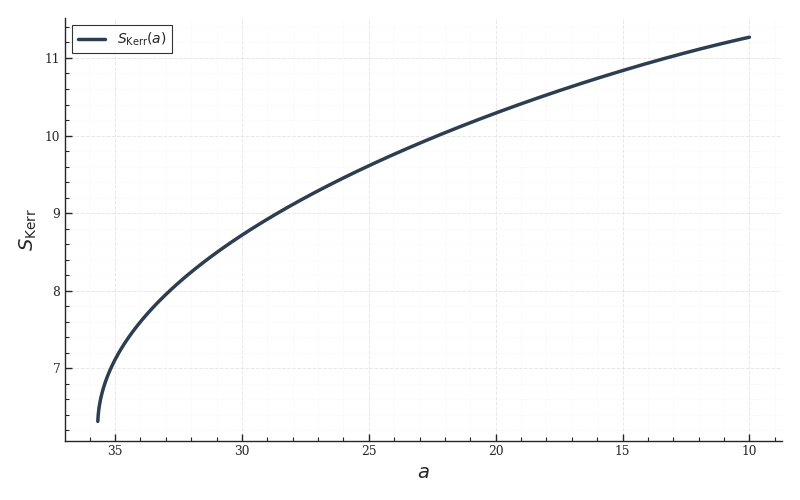

In [26]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_prec,ENT_2PN,label=r"$S_{\rm Kerr}(a)$",color="#2c3e50",lw=2.5)
ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.grid(True,which="major",linestyle="--",linewidth=0.7,alpha=0.45)
ax.minorticks_on()
ax.grid(True,which="minor",linestyle=":",linewidth=0.5,alpha=0.25)
ax.legend(frameon=True,shadow=False,fancybox=False,edgecolor="black",loc="best")
sns.despine()
plt.tight_layout()
plt.show()

### Padé $[2/1]$ extrapolation of the 2PN entropy curve

In this cell we extrapolate the 2PN entropy curve toward smaller separations using a Padé $[2/1]$ approximant. Starting from the valid 2PN data, we first select only finite and physical points satisfying

$$
a>0,
\qquad
M_{\rm tot}^{\rm 2PN}>0.
$$

The fitting data are then sorted with respect to the binary separation $a$, and the fitting variable is chosen as

$$
x = \frac{1}{\sqrt{a}},
$$

which increases as the binary separation decreases. Instead of fitting the entropy directly, we fit separately the 2PN binding energy

$$
E_{\rm bind}^{\rm 2PN}
=

M_{\rm tot}^{\rm 2PN}-m,
$$

and the dimensionless Kerr spin parameter reconstructed from the 2PN total angular momentum,

$$
\chi^{\rm 2PN}
=

\frac{J_{\rm tot}^{\rm 2PN}}
{\left(M_{\rm tot}^{\rm 2PN}\right)^2}.
$$

Only points for which both quantities are finite and satisfy the Kerr bound

$$
|\chi^{\rm 2PN}|\leq 1
$$

are retained in the fit.

Both $E_{\rm bind}^{\rm 2PN}$ and $\chi^{\rm 2PN}$ are fitted with a Padé $[2/1]$ approximant of the form

$$
P_{[2/1]}(x)
=

\frac{a_0+a_1x+a_2x^2}{1+b_1x}.
$$

The fit is performed with a robust least-squares routine using a `soft_l1` loss. A multi-start strategy is used: several initial guesses are tested, and the solution with the smallest cost is retained. The denominator coefficient is constrained by

$$
b_1 \geq 0,
$$

in order to reduce the risk of generating unstable poles in the extrapolated interval.

The weights are chosen as

$$
\sigma(a)
=

\left(
\frac{a}{a_{\min}}
\right),
$$

so that points at smaller separation, where the extrapolation is anchored, have larger statistical weight in the fit.

After the fit, the Padé models are evaluated on the extrapolation interval

$$
1 \leq a \leq 15,
$$

with

$$
x_{\rm extrap}
=
\frac{1}{\sqrt{a_{\rm extrap}}}.
$$

The extrapolated total mass and angular momentum are reconstructed as

$$
M_{\rm extrap}^{\rm 2PN}
=

m+
E_{\rm bind,extrap}^{\rm 2PN},
$$

and

$$
J_{\rm extrap}^{\rm 2PN}
=

\chi_{\rm extrap}^{\rm 2PN}
\left(
M_{\rm extrap}^{\rm 2PN}
\right)^2.
$$

The Kerr entropy is then computed from the reconstructed quantities,

$$
S_{\rm Kerr}
=

2\pi M
\left(
M+
\sqrt{
M^2-\frac{J^2}{M^2}
}
\right).
$$

Only physical extrapolated points are retained, namely those satisfying

$$
M_{\rm extrap}^{\rm 2PN}>0,
\qquad
|\chi_{\rm extrap}^{\rm 2PN}|\leq 1.
$$

The maximum of the extrapolated 2PN entropy curve defines

$$
a_{\max}^{\rm Padé,,2PN},
$$

together with the corresponding values

$$
S_{\max}^{\rm Padé,,2PN},
\qquad
M_{\max}^{\rm Padé,,2PN},
\qquad
J_{\max}^{\rm Padé,,2PN},
\qquad
\chi_{\max}^{\rm Padé,,2PN}.
$$

This separation is then compared with the merger separation predicted by the surrogate model,

$$
a_{\rm merger}^{\rm NR}.
$$

The main diagnostic quantity is therefore

$$
\Delta a
=

\left|
a_{\max}^{\rm Padé,,2PN}
-

a_{\rm merger}^{\rm NR}
\right|.
$$

This provides a direct test of whether the maximum of the 2PN Padé-extrapolated entropy curve occurs close to the surrogate merger separation. The fit costs and the number of function evaluations for both the binding-energy fit and the spin-parameter fit are also stored as diagnostics of the robustness of the extrapolation.


In [16]:
valid_mask_P = (np.isfinite(ENT_2PN)& np.isfinite(a_prec)& np.isfinite(E_tot_2PN)& np.isfinite(J_tot_2PN)& (a_prec > 0)& (E_tot_2PN > 0))
a_valid_P = a_prec[valid_mask_P]
M_valid_P = E_tot_2PN[valid_mask_P]
J_valid_P = J_tot_2PN[valid_mask_P]
S_valid_P = ENT_2PN[valid_mask_P]
sort_idx_P = np.argsort(a_valid_P)
a_fit_P = a_valid_P[sort_idx_P]
M_fit_P = M_valid_P[sort_idx_P]
J_fit_P = J_valid_P[sort_idx_P]
S_fit_P = S_valid_P[sort_idx_P]
x_fit_P = 1.0 / np.sqrt(a_fit_P)

try:
    m_ref_P = float(m1_num + m2_num)
except NameError:
    m_ref_P = 1.0

Ebind_fit_P = M_fit_P - m_ref_P
chi_fit_P = J_fit_P / M_fit_P**2
fit_mask_P = (np.isfinite(x_fit_P)& np.isfinite(Ebind_fit_P)& np.isfinite(chi_fit_P)& (np.abs(chi_fit_P) <= 1.0))
a_fit_P = a_fit_P[fit_mask_P]
x_fit_P = x_fit_P[fit_mask_P]
M_fit_P = M_fit_P[fit_mask_P]
J_fit_P = J_fit_P[fit_mask_P]
S_fit_P = S_fit_P[fit_mask_P]
Ebind_fit_P = Ebind_fit_P[fit_mask_P]
chi_fit_P = chi_fit_P[fit_mask_P]

a_min_fit_P = np.nanmin(a_fit_P)
sigma_fit_P = (a_fit_P / a_min_fit_P)**1.0


def pade_2_1_fit_P(
    x_P,
    y_P,
    sigma_P,
    y_scale_P=None,
    n_starts_P=60,
    random_seed_P=1234,
    loss_P="soft_l1",
    f_scale_P=1.0,
    max_nfev_P=50000,
    progress_label_P="Padé [2/1] fit"
):
    
    x_P = np.asarray(x_P, dtype=float)
    y_P = np.asarray(y_P, dtype=float)
    sigma_P = np.asarray(sigma_P, dtype=float)
    valid_P = (np.isfinite(x_P)& np.isfinite(y_P)& np.isfinite(sigma_P)& (sigma_P > 0))
    x_P = x_P[valid_P]
    y_P = y_P[valid_P]
    sigma_P = sigma_P[valid_P]
    lower_bounds_P = np.array([-np.inf, -np.inf, -np.inf, 0.0], dtype=float)
    upper_bounds_P = np.array([ np.inf,  np.inf,  np.inf, np.inf], dtype=float)
    def residuals_P(params_P):
        y_model_P = pade_2_1(x_P, *params_P)
        res_P = (y_model_P - y_P) / sigma_P
        res_P = np.where(np.isfinite(res_P), res_P, 1.0e12)
        return res_P
    rng_P = np.random.default_rng(random_seed_P)
    starts_P = []
    starts_P.append(np.array([np.nanmedian(y_P),0.0,0.0,0.1],dtype=float))
    for _P in range(n_starts_P - 1):
        starts_P.append(np.array([np.nanmedian(y_P),rng_P.normal(loc=0.0, scale=0.2 * y_scale_P),rng_P.normal(loc=0.0, scale=0.2 * y_scale_P),rng_P.uniform(low=0.0, high=1.0)],dtype=float))
    best_result_P = None
    best_cost_P = np.inf
    last_exception_P = None
    iterator_P = tqdm(starts_P,desc=progress_label_P,total=len(starts_P),leave=True)

    for p0_P in iterator_P:
        try:
            res_P = least_squares(
                residuals_P,
                p0_P,
                bounds=(lower_bounds_P, upper_bounds_P),
                loss=loss_P,
                f_scale=f_scale_P,
                x_scale="jac",
                max_nfev=max_nfev_P
            )
            if res_P.success and np.isfinite(res_P.cost) and res_P.cost < best_cost_P:
                best_result_P = res_P
                best_cost_P = res_P.cost
            iterator_P.set_postfix(best_cost=f"{best_cost_P:.3e}")
        except Exception as exc_P:
            last_exception_P = exc_P
            iterator_P.set_postfix(error=str(exc_P)[:40])
            continue
    if best_result_P is None:
        raise RuntimeError(
            "Fit robusto fallito per Padé [2/1].\n"
            f"Ultima eccezione intercettata: {repr(last_exception_P)}"
        )
    return best_result_P.x, best_result_P

model_name_P = "Padé [2/1]"

N_STARTS_EBIND_P = 10
N_STARTS_CHI_P = 10

popt_Ebind_P, result_Ebind_P = pade_2_1_fit_P(
    x_P=x_fit_P,
    y_P=Ebind_fit_P,
    sigma_P=sigma_fit_P,
    y_scale_P=np.nanstd(Ebind_fit_P),
    n_starts_P=N_STARTS_EBIND_P,
    random_seed_P=1234,
    loss_P="soft_l1",
    f_scale_P=1.0,
    max_nfev_P=30000,
    progress_label_P=r"Fitting E_bind with Padé [2/1]"
)

popt_chi_P, result_chi_P = pade_2_1_fit_P(
    x_P=x_fit_P,
    y_P=chi_fit_P,
    sigma_P=sigma_fit_P,
    y_scale_P=np.nanstd(chi_fit_P),
    n_starts_P=N_STARTS_CHI_P,
    random_seed_P=4321,
    loss_P="soft_l1",
    f_scale_P=1.0,
    max_nfev_P=15000,
    progress_label_P=r"Fitting chi with Padé [2/1]"
)

a_extrap_P = np.linspace(15.0, 1.0, 10000)
x_extrap_P = 1.0 / np.sqrt(a_extrap_P)
Ebind_extrap_P = pade_2_1(x_extrap_P, *popt_Ebind_P)
chi_extrap_P = pade_2_1(x_extrap_P, *popt_chi_P)
M_extrap_P = m_ref_P + Ebind_extrap_P
J_extrap_P = chi_extrap_P * M_extrap_P**2

physical_mask_P = (np.isfinite(M_extrap_P)& np.isfinite(chi_extrap_P)& np.isfinite(J_extrap_P)& (M_extrap_P > 0)& (np.abs(chi_extrap_P) <= 1.0))
ENT_extrap_P = np.full_like(a_extrap_P, np.nan, dtype=float)
ENT_extrap_P[physical_mask_P] = entropy(M_extrap_P[physical_mask_P],J_extrap_P[physical_mask_P])

if np.all(np.isnan(ENT_extrap_P)):
    raise RuntimeError(
        "La curva Padé [2/1] estrapolata non contiene punti fisici validi."
    )

idx_max_P = np.nanargmax(ENT_extrap_P)
a_max_entropy_P = a_extrap_P[idx_max_P]
S_max_entropy_P = ENT_extrap_P[idx_max_P]
M_at_max_P = M_extrap_P[idx_max_P]
J_at_max_P = J_extrap_P[idx_max_P]
chi_at_max_P = chi_extrap_P[idx_max_P]
delta_a_P = np.abs(a_max_entropy_P - a_merger)
accepted_results_P = [
    {
        "model": model_name_P,
        "a_max": a_max_entropy_P,
        "S_max": S_max_entropy_P,
        "M_at_max": M_at_max_P,
        "J_at_max": J_at_max_P,
        "chi_at_max": chi_at_max_P,
        "delta_a": delta_a_P,
        "cost_Ebind": result_Ebind_P.cost,
        "cost_chi": result_chi_P.cost,
        "nfev_Ebind": result_Ebind_P.nfev,
        "nfev_chi": result_chi_P.nfev
    }
]

results_df_P = pd.DataFrame(accepted_results_P)
pade_curves_P = {
    model_name_P: {
        "a_extrap": a_extrap_P,
        "x_extrap": x_extrap_P,
        "Ebind_extrap": Ebind_extrap_P,
        "M_extrap": M_extrap_P,
        "J_extrap": J_extrap_P,
        "chi_extrap": chi_extrap_P,
        "ENT_extrap": ENT_extrap_P,
        "popt_Ebind": popt_Ebind_P,
        "popt_chi": popt_chi_P,
        "result_Ebind": result_Ebind_P,
        "result_chi": result_chi_P,
        "physical_mask": physical_mask_P
    }
}

print("============================================================")
print("PADÉ [2/1] FIT ON E_bind AND chi")
print("============================================================")
print(f"Maximum with Padé [2/1] at a = {a_max_entropy_P:.6f}")
print(f"NR Merger a                   = {a_merger:.6f}")
print(f"Delta a                       = {delta_a_P:.6f}")
print("============================================================")

Fitting E_bind with Padé [2/1]:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting chi with Padé [2/1]:   0%|          | 0/10 [00:00<?, ?it/s]

PADÉ [2/1] FIT ON E_bind AND chi
Maximum with Padé [2/1] at a = 4.784578
NR Merger a                   = 3.477838
Delta a                       = 1.306740


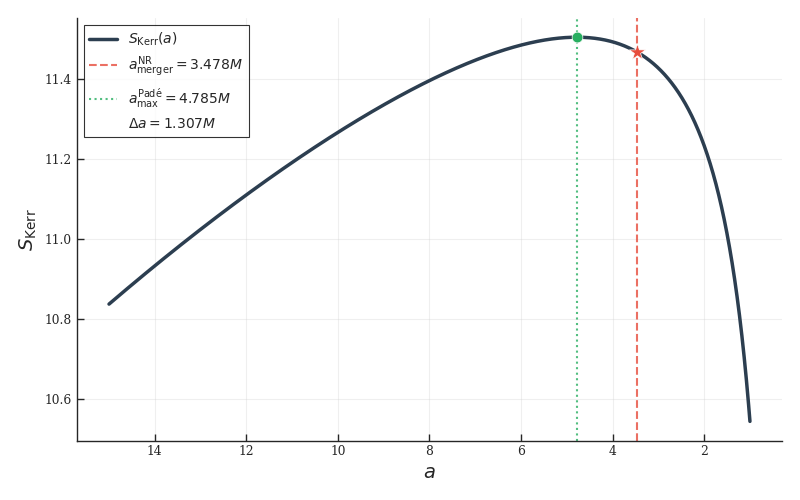

In [17]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

sort_idx_P = np.argsort(a_extrap_P)
a_sorted_P = a_extrap_P[sort_idx_P]
ent_sorted_P = ENT_extrap_P[sort_idx_P]
valid_interp_mask_P = (np.isfinite(a_sorted_P)&np.isfinite(ent_sorted_P))
a_sorted_valid_P = a_sorted_P[valid_interp_mask_P]
ent_sorted_valid_P = ent_sorted_P[valid_interp_mask_P]
y_at_merger_P = np.interp(a_merger,a_sorted_valid_P,ent_sorted_valid_P)
y_at_max_entropy_P = np.interp(a_max_entropy_P,a_sorted_valid_P,ent_sorted_valid_P)
delta_a_P = np.abs(a_max_entropy_P - a_merger)

fig_P, ax_P = plt.subplots(figsize=(8, 5))
ax_P.plot(a_extrap_P,ENT_extrap_P,label=r"$S_{\rm Kerr}(a)$",color="#2c3e50",lw=2.5)
ax_P.scatter(a_merger,y_at_merger_P,marker="*",s=150,color="#e74c3c",zorder=5,edgecolor="white",linewidth=0.5)
ax_P.scatter(a_max_entropy_P,y_at_max_entropy_P,marker="o",s=60,color="#27ae60",zorder=5,edgecolor="white",linewidth=0.5)
ax_P.axvline(a_merger,color="#e74c3c",linestyle="--",lw=1.5,alpha=0.8,label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax_P.axvline(a_max_entropy_P,color="#27ae60",linestyle=":",lw=1.5,alpha=0.8,label=fr"$a_{{\max}}^{{\rm Pad\acute{{e}}}}={a_max_entropy_P:.3f}M$")
ax_P.plot([],[]," ",label=fr"$\Delta a={delta_a_P:.3f}M$")
ax_P.invert_xaxis()
ax_P.set_xlabel(r"$a$")
ax_P.set_ylabel(r"$S_{\rm Kerr}$")
ax_P.legend(frameon=True,shadow=False,fancybox=False,edgecolor="black",loc="best")
sns.despine()
plt.tight_layout()
plt.show()

### Taylor extrapolation of the 2PN entropy curve

In this cell we extrapolate the 2PN entropy curve toward smaller separations using a Taylor polynomial model. Starting from the valid 2PN data, we first select only finite and physical points satisfying

$$
a>0,
\qquad
M_{\rm tot}^{\rm 2PN}>0.
$$

The corresponding arrays for the separation, total mass, total angular momentum and entropy are then defined as

$$
a,
\qquad
M_{\rm tot}^{\rm 2PN},
\qquad
J_{\rm tot}^{\rm 2PN},
\qquad
S_{\rm Kerr}^{\rm 2PN}.
$$

The data are sorted with respect to the binary separation $a$, and the fitting variable is chosen as

$$
x=\frac{1}{\sqrt{a}},
$$

which increases as the binary separation decreases.

As in the Padé extrapolation, the entropy is not fitted directly. Instead, we fit separately the 2PN binding energy

$$
E_{\rm bind}^{\rm 2PN}
=

M_{\rm tot}^{\rm 2PN}-m,
$$

and the dimensionless Kerr spin parameter

$$
\chi^{\rm 2PN}
=

\frac{J_{\rm tot}^{\rm 2PN}}
{\left(M_{\rm tot}^{\rm 2PN}\right)^2}.
$$

Only the points for which both quantities are finite and satisfy the Kerr bound

$$
|\chi^{\rm 2PN}|\leq 1
$$

are retained in the fit. A minimum number of valid points is also required in order to avoid performing an unreliable extrapolation.

The fitting weights are chosen as

$$
\sigma(a)
=

\left(
\frac{a}{a_{\min}}
\right),
$$

so that points at smaller separation have larger statistical weight in the fit.

The Taylor model is written in terms of the rescaled variable

$$
z
=

\frac{x-x_{\rm center}}{x_{\rm scale}},
$$

where

$$
x_{\rm center}
=

\langle x\rangle,
\qquad
x_{\rm scale}
=

{\rm std}(x).
$$

This rescaling improves the numerical conditioning of the polynomial fit. The fitted model has the form

$$
T_n(z)
=

c_0+c_1 z+c_2 z^2+\cdots+c_n z^n.
$$

In this implementation, both the binding energy and the Kerr spin parameter are fitted with cubic Taylor polynomials,

$$
T_3(z)
=

c_0+c_1 z+c_2 z^2+c_3 z^3.
$$

Therefore,

$$
E_{\rm bind}^{\rm 2PN}(x)
\simeq
T_3^{E_{\rm bind}}(z),
$$

and

$$
\chi^{\rm 2PN}(x)
\simeq
T_3^{\chi}(z).
$$

The fit is performed with a robust least-squares routine using a `soft_l1` loss. As an initial guess, a weighted polynomial fit is computed with weights proportional to $1/\sigma(a)$. The robust fit is then used to reduce the influence of possible outliers in the 2PN data.

After the fit, the Taylor models are evaluated on the extrapolation interval

$$
1\leq a \leq 15,
$$

with

$$
x_{\rm extrap}
=

\frac{1}{\sqrt{a_{\rm extrap}}}.
$$

The extrapolated total mass is reconstructed as

$$
M_{\rm extrap}^{\rm 2PN}
=

m+
E_{\rm bind,extrap}^{\rm 2PN},
$$

while the extrapolated angular momentum is reconstructed from the extrapolated Kerr spin parameter as

$$
J_{\rm extrap}^{\rm 2PN}
=

\chi_{\rm extrap}^{\rm 2PN}
\left(
M_{\rm extrap}^{\rm 2PN}
\right)^2.
$$

The Kerr entropy is then computed from the reconstructed quantities,

$$
S_{\rm Kerr}
=

2\pi M
\left(
M+
\sqrt{
M^2-\frac{J^2}{M^2}
}
\right).
$$

Only physical extrapolated points are retained, namely those satisfying

$$
M_{\rm extrap}^{\rm 2PN}>0,
\qquad
|\chi_{\rm extrap}^{\rm 2PN}|\leq 1,
\qquad
|J_{\rm extrap}^{\rm 2PN}|
\leq
\left(M_{\rm extrap}^{\rm 2PN}\right)^2.
$$

The maximum of the Taylor-extrapolated entropy curve defines

$$
a_{\max}^{\rm Taylor,,2PN},
$$

together with the corresponding values

$$
S_{\max}^{\rm Taylor,,2PN},
\qquad
M_{\max}^{\rm Taylor,,2PN},
\qquad
J_{\max}^{\rm Taylor,,2PN},
\qquad
\chi_{\max}^{\rm Taylor,,2PN}.
$$

This separation is then compared with the merger separation predicted by the surrogate model,

$$
a_{\rm merger}^{\rm NR}.
$$

The main diagnostic quantity is therefore

$$
\Delta a
=

\left|
a_{\max}^{\rm Taylor,,2PN}
-

a_{\rm merger}^{\rm NR}
\right|.
$$

This provides a direct test of whether the maximum of the Taylor-extrapolated 2PN entropy curve occurs close to the surrogate merger separation. Boundary checks are also performed: if the entropy maximum is located at the edge of the extrapolation interval, the peak may not be properly resolved and the extrapolation should be interpreted with caution. The fit costs and the number of function evaluations for both the binding-energy fit and the spin-parameter fit are stored as additional diagnostics of the robustness of the result.


In [18]:
valid_mask_T = (np.isfinite(ENT_2PN)& np.isfinite(a_prec)& np.isfinite(E_tot_2PN)& np.isfinite(J_tot_2PN)& (a_prec > 0)& (E_tot_2PN > 0))
a_valid_T = a_prec[valid_mask_T]
M_valid_T = E_tot_2PN[valid_mask_T]
J_valid_T = J_tot_2PN[valid_mask_T]
S_valid_T = ENT_2PN[valid_mask_T]
sort_idx_T = np.argsort(a_valid_T)
a_fit_T = a_valid_T[sort_idx_T]
M_fit_T = M_valid_T[sort_idx_T]
J_fit_T = J_valid_T[sort_idx_T]
S_fit_T = S_valid_T[sort_idx_T]
x_fit_T = 1.0 / np.sqrt(a_fit_T)

try:
    m_ref_T = float(m1_num + m2_num)
except NameError:
    m_ref_T = 1.0

Ebind_fit_T = M_fit_T - m_ref_T
chi_fit_T = J_fit_T / M_fit_T**2
fit_mask_T = (np.isfinite(x_fit_T)& np.isfinite(Ebind_fit_T)& np.isfinite(chi_fit_T)& (np.abs(chi_fit_T) <= 1.0))
a_fit_T = a_fit_T[fit_mask_T]
x_fit_T = x_fit_T[fit_mask_T]
M_fit_T = M_fit_T[fit_mask_T]
J_fit_T = J_fit_T[fit_mask_T]
S_fit_T = S_fit_T[fit_mask_T]
Ebind_fit_T = Ebind_fit_T[fit_mask_T]
chi_fit_T = chi_fit_T[fit_mask_T]

if len(x_fit_T) < 20:
    raise RuntimeError(
        f"Too few valid points for a reliable Taylor fit: {len(x_fit_T)}"
    )

a_min_fit_T = np.nanmin(a_fit_T)
sigma_fit_T = (a_fit_T / a_min_fit_T)**1.0

def taylor_model_scaled_T(x_T, coeffs_T, x_center_T, x_scale_T):
    
    x_T = np.asarray(x_T, dtype=float)
    z_T = (x_T - x_center_T) / x_scale_T
    y_T = np.zeros_like(z_T, dtype=float)
    for k_T, ck_T in enumerate(coeffs_T):
        y_T += ck_T * z_T**k_T
    return y_T

def taylor_fit_T(
    x_T,
    y_T,
    sigma_T,
    degree_T=3,
    loss_T="soft_l1",
    f_scale_T=1.0,
    max_nfev_T=50000,
    progress_label_T="Taylor fit"
):

    x_T = np.asarray(x_T, dtype=float)
    y_T = np.asarray(y_T, dtype=float)
    sigma_T = np.asarray(sigma_T, dtype=float)

    valid_T = (
        np.isfinite(x_T)
        & np.isfinite(y_T)
        & np.isfinite(sigma_T)
        & (sigma_T > 0)
    )

    x_T = x_T[valid_T]
    y_T = y_T[valid_T]
    sigma_T = sigma_T[valid_T]

    if len(x_T) <= degree_T + 1:
        raise RuntimeError(
            f"Not enough points for Taylor degree {degree_T}: "
            f"n_points = {len(x_T)}."
        )
    x_center_T = np.nanmean(x_T)
    x_scale_T = np.nanstd(x_T)
    if not np.isfinite(x_scale_T) or x_scale_T == 0.0:
        x_scale_T = 1.0

    z_T = (x_T - x_center_T) / x_scale_T
    poly_coeff_high_to_low_T = np.polyfit(z_T,y_T,deg=degree_T,w=1.0 / sigma_T)
    p0_T = poly_coeff_high_to_low_T[::-1]
    def residuals_T(coeffs_T):
        y_model_T = taylor_model_scaled_T(x_T,coeffs_T,x_center_T=x_center_T,x_scale_T=x_scale_T)
        res_T = (y_model_T - y_T) / sigma_T
        res_T = np.where(np.isfinite(res_T), res_T, 1.0e12)
        return res_T
    result_T = least_squares(residuals_T,p0_T,loss=loss_T,f_scale=f_scale_T,x_scale="jac",max_nfev=max_nfev_T)
    if not result_T.success:
        raise RuntimeError(
            f"{progress_label_T} failed: {result_T.message}"
        )
    return result_T.x, x_center_T, x_scale_T, result_T

model_name_T = "Taylor degree 3"

TAYLOR_DEGREE_EBIND_T = 3
TAYLOR_DEGREE_CHI_T = 3

coeff_Ebind_T, x_center_Ebind_T, x_scale_Ebind_T, result_Ebind_T = taylor_fit_T(
    x_T=x_fit_T,
    y_T=Ebind_fit_T,
    sigma_T=sigma_fit_T,
    degree_T=TAYLOR_DEGREE_EBIND_T,
    loss_T="soft_l1",
    f_scale_T=1.0,
    max_nfev_T=30000,
    progress_label_T="Fitting E_bind with Taylor"
)

coeff_chi_T, x_center_chi_T, x_scale_chi_T, result_chi_T = taylor_fit_T(
    x_T=x_fit_T,
    y_T=chi_fit_T,
    sigma_T=sigma_fit_T,
    degree_T=TAYLOR_DEGREE_CHI_T,
    loss_T="soft_l1",
    f_scale_T=1.0,
    max_nfev_T=15000,
    progress_label_T="Fitting chi with Taylor"
)


a_extrap_T = np.linspace(15.0, 1.0, 10000)
x_extrap_T = 1.0 / np.sqrt(a_extrap_T)

Ebind_extrap_T = taylor_model_scaled_T(x_extrap_T,coeff_Ebind_T,x_center_T=x_center_Ebind_T,x_scale_T=x_scale_Ebind_T)
chi_extrap_T = taylor_model_scaled_T(x_extrap_T,coeff_chi_T,x_center_T=x_center_chi_T,x_scale_T=x_scale_chi_T)
M_extrap_T = m_ref_T + Ebind_extrap_T
J_extrap_T = chi_extrap_T * M_extrap_T**2

physical_mask_T = (np.isfinite(M_extrap_T)& np.isfinite(chi_extrap_T)& np.isfinite(J_extrap_T)& (M_extrap_T > 0)& (np.abs(chi_extrap_T) <= 1.0)& (np.abs(J_extrap_T) <= M_extrap_T**2))
ENT_extrap_T = np.full_like(a_extrap_T, np.nan, dtype=float)
ENT_extrap_T[physical_mask_T] = entropy(M_extrap_T[physical_mask_T],J_extrap_T[physical_mask_T])

if np.all(np.isnan(ENT_extrap_T)):
    raise RuntimeError(
        "The Taylor-extrapolated curve contains no valid physical points."
    )


idx_max_T = np.nanargmax(ENT_extrap_T)
a_max_entropy_T = a_extrap_T[idx_max_T]
S_max_entropy_T = ENT_extrap_T[idx_max_T]
M_at_max_T = M_extrap_T[idx_max_T]
J_at_max_T = J_extrap_T[idx_max_T]
chi_at_max_T = chi_extrap_T[idx_max_T]
delta_a_T = np.abs(a_max_entropy_T - a_merger)

if idx_max_T == 0:
    print(
        "WARNING: Taylor entropy maximum is at the largest a boundary. "
        "The peak may not be resolved."
    )
if idx_max_T == len(a_extrap_T) - 1:
    print(
        "WARNING: Taylor entropy maximum is at the smallest a boundary. "
        "The entropy may still be increasing."
    )
if not (np.nanmin(a_extrap_T) <= a_merger <= np.nanmax(a_extrap_T)):
    print(
        f"WARNING: a_merger = {a_merger:.6f} is outside the extrapolation range "
        f"[{np.nanmin(a_extrap_T):.6f}, {np.nanmax(a_extrap_T):.6f}]."
    )


accepted_results_T = [
    {
        "model": model_name_T,
        "degree_Ebind": TAYLOR_DEGREE_EBIND_T,
        "degree_chi": TAYLOR_DEGREE_CHI_T,
        "a_max": a_max_entropy_T,
        "S_max": S_max_entropy_T,
        "M_at_max": M_at_max_T,
        "J_at_max": J_at_max_T,
        "chi_at_max": chi_at_max_T,
        "delta_a": delta_a_T,
        "cost_Ebind": result_Ebind_T.cost,
        "cost_chi": result_chi_T.cost,
        "nfev_Ebind": result_Ebind_T.nfev,
        "nfev_chi": result_chi_T.nfev
    }
]

results_taylor_df_T = pd.DataFrame(accepted_results_T)

taylor_curves_T = {
    model_name_T: {
        "a_extrap": a_extrap_T,
        "x_extrap": x_extrap_T,
        "Ebind_extrap": Ebind_extrap_T,
        "M_extrap": M_extrap_T,
        "J_extrap": J_extrap_T,
        "chi_extrap": chi_extrap_T,
        "ENT_extrap": ENT_extrap_T,
        "coeff_Ebind": coeff_Ebind_T,
        "coeff_chi": coeff_chi_T,
        "x_center_Ebind": x_center_Ebind_T,
        "x_scale_Ebind": x_scale_Ebind_T,
        "x_center_chi": x_center_chi_T,
        "x_scale_chi": x_scale_chi_T,
        "result_Ebind": result_Ebind_T,
        "result_chi": result_chi_T,
        "physical_mask": physical_mask_T
    }
}

print("============================================================")
print("TAYLOR FIT ON E_bind AND chi")
print("============================================================")
print(f"Taylor degree E_bind             = {TAYLOR_DEGREE_EBIND_T}")
print(f"Taylor degree chi                = {TAYLOR_DEGREE_CHI_T}")
print()
print(f"Maximum with Taylor at a          = {a_max_entropy_T:.6f}")
print(f"NR Merger a                       = {a_merger:.6f}")
print(f"Delta a                           = {delta_a_T:.6f}")
print("============================================================")

TAYLOR FIT ON E_bind AND chi
Taylor degree E_bind             = 3
Taylor degree chi                = 3

Maximum with Taylor at a          = 3.880088
NR Merger a                       = 3.477838
Delta a                           = 0.402250


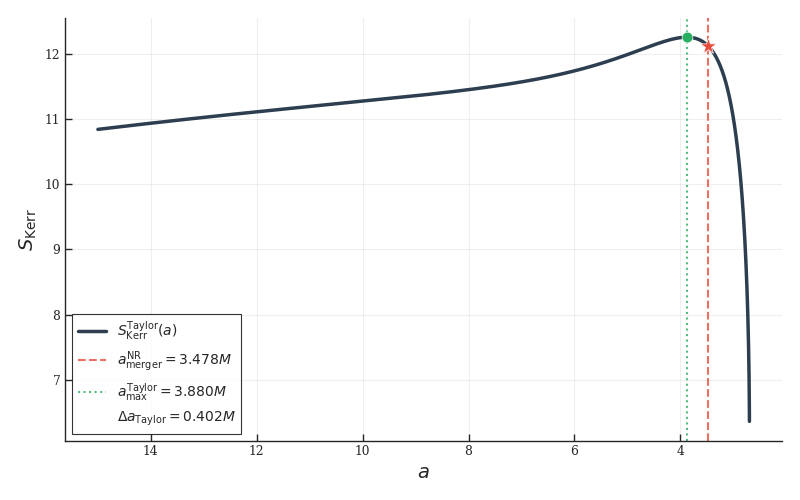

In [19]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

model_name = "Taylor degree 3"
a_taylor = taylor_curves_T[model_name]["a_extrap"]
ENT_taylor = taylor_curves_T[model_name]["ENT_extrap"]
a_max_taylor = results_taylor_df_T.loc[0, "a_max"]
S_max_taylor = results_taylor_df_T.loc[0, "S_max"]
delta_a_taylor = np.abs(a_max_taylor - a_merger)
sort_idx = np.argsort(a_taylor)
a_sorted = a_taylor[sort_idx]
ent_sorted = ENT_taylor[sort_idx]
valid_interp_mask = (np.isfinite(a_sorted)&np.isfinite(ent_sorted))
a_sorted_valid = a_sorted[valid_interp_mask]
ent_sorted_valid = ent_sorted[valid_interp_mask]
y_at_merger = np.interp(a_merger,a_sorted_valid,ent_sorted_valid)
y_at_max_taylor = np.interp(a_max_taylor,a_sorted_valid,ent_sorted_valid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_taylor,ENT_taylor,label=r"$S_{\rm Kerr}^{\rm Taylor}(a)$",color="#2c3e50",lw=2.5)
ax.scatter(a_merger,y_at_merger,marker="*",s=150,color="#e74c3c",zorder=5,edgecolor="white",linewidth=0.5)
ax.scatter(a_max_taylor,y_at_max_taylor,marker="o",s=60,color="#27ae60",zorder=5,edgecolor="white",linewidth=0.5)
ax.axvline(a_merger,color="#e74c3c",linestyle="--",lw=1.5,alpha=0.8,label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax.axvline(a_max_taylor,color="#27ae60",linestyle=":",lw=1.5,alpha=0.8,label=fr"$a_{{\max}}^{{\rm Taylor}}={a_max_taylor:.3f}M$")
ax.plot([],[]," ",label=fr"$\Delta a_{{\rm Taylor}}={delta_a_taylor:.3f}M$")
ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.legend(frameon=True,shadow=False,fancybox=False,edgecolor="black",loc="best")
sns.despine()
plt.tight_layout()
plt.show()